In [1]:
#=nb

In [29]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [30]:
train = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor()
)
test = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

In [31]:
img,lbl = train[0]
img = img.reshape(1,28,28)
img.shape

torch.Size([1, 28, 28])

In [33]:
test_dataloader = DataLoader(test, batch_size = 32, shuffle = True)
train_dataloader = DataLoader(train, batch_size = 32, shuffle = True)

In [32]:
divice = ("cuda"
   if torch.cuda.is_available()
   else "mps"
   if torch.backends.mps.is_available()
   else "cpu")
divice

'cpu'

In [34]:
class ConvNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Conv2d(in_channels = 1, out_channels = 12, kernel_size = 3, stride = 2, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2),
        nn.Conv2d(in_channels = 12, out_channels = 24, kernel_size = 3, stride = 2, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
        )
    out = torch.zeros(1,28,28)
    output_shape = self.layer(out).flatten().shape[0]
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(output_shape, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
        )
  def forward(self, x):
    x = self.layer(x)
    x = self.classifier(x)
    return x
model = ConvNet().to(divice)
model

ConvNet(
  (layer): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(12, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=96, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [36]:
def train(model,dataloader, optimizer, loss_fn, print_every = 1):
  model.train()
  size = len(dataloader.dataset)
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(divice), y.to(divice)
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % print_every == 0:
      current = (batch + 1) * len(X)
      print(f"loss: {loss.item():.4f},[Current: {current}/{size}]")


In [37]:
def test(model, dataloader, loss_fn, print_every = 1):
  model.eval()
  num_batches = len(dataloader)
  test_loss, correct = 0 , 0
  with torch.no_grad():
    for X,y in dataloader:
      X,y = X.to(divice), y.to(divice)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= len(dataloader.dataset)
  print(f"Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [38]:
epoches = 6
for t in range(epoches):
  print(f"Epoch {t+1}\n-------------------------------")
  train(model, train_dataloader, optimizer, loss_fn, print_every = 1000)
  test(model, test_dataloader, loss_fn, print_every = 10)
print("Done!")

Epoch 1
-------------------------------
loss: 2.3036,[Current: 32/60000]
loss: 0.1576,[Current: 32032/60000]
Accuracy: 95.2%, Avg loss: 0.145990 

Epoch 2
-------------------------------
loss: 0.2462,[Current: 32/60000]
loss: 0.0987,[Current: 32032/60000]
Accuracy: 97.0%, Avg loss: 0.096955 

Epoch 3
-------------------------------
loss: 0.0542,[Current: 32/60000]
loss: 0.0382,[Current: 32032/60000]
Accuracy: 97.1%, Avg loss: 0.091465 

Epoch 4
-------------------------------
loss: 0.1779,[Current: 32/60000]
loss: 0.0941,[Current: 32032/60000]
Accuracy: 97.0%, Avg loss: 0.094516 

Epoch 5
-------------------------------
loss: 0.0263,[Current: 32/60000]
loss: 0.1640,[Current: 32032/60000]
Accuracy: 97.8%, Avg loss: 0.068544 

Epoch 6
-------------------------------
loss: 0.0260,[Current: 32/60000]
loss: 0.0890,[Current: 32032/60000]
Accuracy: 98.1%, Avg loss: 0.058045 

Done!


In [39]:
torch.save(model.state_dict(), "model.pth")
print("model saved")

model saved


In [40]:
model = ConvNet().to(divice)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [41]:
classes = {
    0 : "zero",
    1 : "one",
    2 : "two",
    3 : "three",
    4 : "four",
    5 : "five",
    6 : "six",
    7 : "seven",
    8 : "eight",
    9 : "nine"
}

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

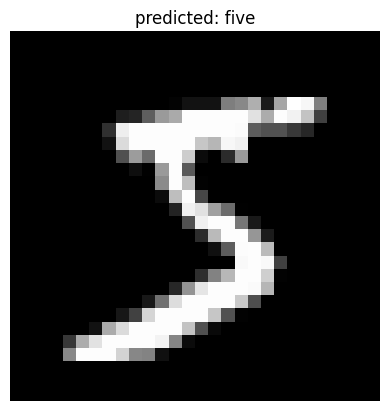

In [43]:
pred = model(img.reshape(1,1,28,28).to(divice))
predicted, correct = classes[pred.argmax(1).item()], classes[lbl]
plt.imshow(img.reshape(28,28), cmap = "gray")
plt.title(f"predicted: {predicted}")
plt.axis(False)